# TECH 405 RNN Hackathon: SMS Spam Detection
### Shreya Tiwari

**Goal:** Build a text classifier that decides whether an SMS message is `spam` or `ham` (not spam), using a Recurrent Neural Network (RNN/LSTM) built in PyTorch.

**Dataset:** SMS Spam Collection Dataset (from the hackathon announcement) — 5,572 labeled SMS messages.

**Why this is a sequence problem:** A text message is not just a "bag" of random words — the **order** of words matters, and meaning builds up word by word as you read the sentence. For example, "call to win a free prize" reads very differently depending on word order and context building up over time. RNNs and LSTMs are designed exactly for this: they read a sequence one token (word) at a time and carry forward a "memory" (hidden state) of what came before, which makes them a natural fit for classifying text.

**Targets for this hackathon:**
- Baseline accuracy to beat: **86.6%**
- Stretch target: **96%**

This notebook trains an LSTM-based classifier from scratch (no pretrained embeddings or models), evaluates it on a held-out 20% test set, and reports the final test accuracy compared against the baseline and target.


## 1. Load the Dataset and Explore It

In this first cell, we read the `spam.csv` file into a table-like structure called a pandas DataFrame, which makes it easy to inspect and manipulate the data. This particular file has some extra empty columns that came from how the CSV was originally saved, so we keep only the two columns that actually matter and rename them to something clearer: `label` (whether the message is ham or spam) and `text` (the actual SMS content). The file also uses a slightly different text encoding than the usual default, so we tell pandas to read it as `latin-1` to avoid errors. Once the data is loaded, we print out the overall shape of the dataset (how many rows and columns it has), count how many messages fall into each label category, and display the first ten rows so we can see what real examples look like. Doing this kind of exploration first is important because it helps us understand what we are working with before we start building anything: it tells us roughly how much data we have, whether the two classes are balanced or not, and what the raw text looks like, all of which will guide the cleaning and modeling decisions we make later.

In [ ]:
import pandas as pd

# Load the dataset 
df = pd.read_csv("spam.csv", encoding="latin-1")
df = df[["v1", "v2"]]
df.columns = ["label", "text"]

print("Dataset shape:", df.shape)
print()
print("Label counts:")
print(df["label"].value_counts())
print()
print("Sample rows:")
df.head(10)


Dataset shape: (5572, 2)

Label counts:
label
ham     4825
spam     747
Name: count, dtype: int64

Sample rows:


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


This second cell takes a closer look at how long each message is, measured in number of words. We create a new column called `word_count` by splitting each message on whitespace and counting the pieces, and then we print summary statistics such as the average length, the shortest and longest messages, and how the lengths are spread out. The reason we bother doing this is practical: later on, when we prepare the text for the neural network, we will need to decide on a single fixed sequence length that every message gets padded or trimmed to. Looking at the distribution of word counts now, before we make that decision, lets us pick a sensible number rather than guessing blindly, so that we do not accidentally cut off too much information from long messages or waste computation padding very short ones with too many empty slots.

In [2]:
df["word_count"] = df["text"].apply(lambda x: len(x.split()))
print(df["word_count"].describe())


count    5572.000000
mean       15.494436
std        11.329427
min         1.000000
25%         7.000000
50%        12.000000
75%        23.000000
max       171.000000
Name: word_count, dtype: float64


## 2. Data Preprocessing and Tokenization

This cell prepares the raw text so that it can eventually be turned into numbers a neural network can understand. First, we define a `clean_text` function that lowercases every message and removes punctuation and special characters, so that words like "Free!!!" and "free" are treated as the exact same word instead of being seen as two different tokens. It also collapses any extra spaces so the text is tidy. Next, we define a `tokenize` function that takes this cleaned text and splits it into a list of individual words, a process known as tokenization. We then apply this tokenizer to every message in the dataset and store the result in a new `tokens` column, and finally print a few examples side by side with the original text so we can visually confirm the cleaning and splitting worked as expected. This step matters because raw sentences cannot be fed directly into a model; breaking them down into clean, consistent word tokens is the necessary first step before we can convert those words into numeric identifiers in the next section.

In [3]:
import re
from collections import Counter

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)   # remove punctuation/special chars
    text = re.sub(r"\s+", " ", text).strip()    # collapse extra whitespace
    return text

def tokenize(text):
    return clean_text(text).split()

df["tokens"] = df["text"].apply(tokenize)
df[["text", "tokens"]].head(5)


,text,tokens
0,"Go until jurong point, crazy.. Available only ...","[go, until, jurong, point, crazy, available, o..."
1,Ok lar... Joking wif u oni...,"[ok, lar, joking, wif, u, oni]"
2,Free entry in 2 a wkly comp to win FA Cup fina...,"[free, entry, in, 2, a, wkly, comp, to, win, f..."
3,U dun say so early hor... U c already then say...,"[u, dun, say, so, early, hor, u, c, already, t..."
4,"Nah I don't think he goes to usf, he lives aro...","[nah, i, don, t, think, he, goes, to, usf, he,..."


## 3. Train/Test Split (Fixed 80/20)

Here we split the full dataset into two separate pieces: a training set that the model will actually learn from, and a test set that will be kept completely untouched until the very end, when we measure the final accuracy. We convert the text labels "ham" and "spam" into the numbers 0 and 1, since machine learning models work with numeric targets rather than text labels. The split itself uses scikit-learn's `train_test_split` function with `test_size=0.20`, meaning eighty percent of the messages go into training and twenty percent go into testing, and we set a fixed `random_state` so that anyone re-running this notebook gets exactly the same split every time, making the results reproducible. We also use `stratify` on the label column so that both the training and test sets keep roughly the same proportion of spam and ham messages as the original dataset, which avoids accidentally ending up with a test set that has almost no spam examples in it. Finally, we print the shapes of both sets and the label balance in each, to confirm the split behaved as expected.

In [4]:
from sklearn.model_selection import train_test_split

df["label_num"] = df["label"].map({"ham": 0, "spam": 1})

RANDOM_SEED = 42  # fixed seed so the split is always the same

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=df["label_num"],  # keep the same spam/ham ratio in both splits
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print()
print("Train label balance:")
print(train_df["label"].value_counts(normalize=True))
print()
print("Test label balance:")
print(test_df["label"].value_counts(normalize=True))


Train shape: (4457, 5)
Test shape: (1115, 5)

Train label balance:
label
ham     0.865829
spam    0.134171
Name: proportion, dtype: float64

Test label balance:
label
ham     0.866368
spam    0.133632
Name: proportion, dtype: float64


This cell builds the vocabulary, which is essentially a dictionary that assigns a unique whole number to every distinct word the model is allowed to recognize. Importantly, we build this vocabulary using only the training messages, deliberately ignoring the test set completely at this stage. We first count how often every word appears across the training tokens, and then only keep words that show up at least twice, which helps filter out rare typos, misspellings, or one-off noise that would not be useful for the model to learn from anyway. We reserve the special index 0 for a padding token, used to fill in short messages up to a fixed length, and index 1 for an "unknown" token, which will be used for any word encountered later in the test set that was never seen during training. Building the vocabulary strictly from training data is a deliberate choice to prevent what is called data leakage, where information from the test set accidentally influences training decisions, which would make our final accuracy score misleadingly optimistic.

In [5]:
# Build the vocabulary using ONLY the training data (no test-set leakage)
word_counts = Counter()
for tokens in train_df["tokens"]:
    word_counts.update(tokens)

# Keep words that appear at least twice, to filter out rare typos/noise
MIN_FREQ = 2
vocab = {"<PAD>": 0, "<UNK>": 1}
for word, count in word_counts.items():
    if count >= MIN_FREQ:
        vocab[word] = len(vocab)

VOCAB_SIZE = len(vocab)
print("Vocabulary size:", VOCAB_SIZE)


Vocabulary size: 3755


## 4. Sequence Preparation

This cell turns every message into a fixed-length sequence of numbers that PyTorch can process in batches. We define an `encode` function that looks up each word's integer ID in the vocabulary we just built, using the unknown-word ID for anything not found there. Since real messages vary a lot in length, we set a constant `MAX_LEN` of 30 words, based on what we learned from the word count statistics earlier, and every message is either padded with zeros at the end if it is shorter than that, or cut off if it is longer. We then wrap the encoded training and test data inside a custom PyTorch `Dataset` class, which simply knows how to return one input sequence and its label at a time, and we use `DataLoader` objects to automatically group these into shuffled batches of 32 messages for training and non-shuffled batches for testing. At the end of the cell we print the shape of one batch of inputs and labels along with a single example encoded sequence, just to visually confirm that everything is the correct size and format before we start building the actual model.

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader

MAX_LEN = 30  # covers the vast majority of SMS messages (see word_count stats above)

def encode(tokens, vocab, max_len=MAX_LEN):
    ids = [vocab.get(tok, vocab["<UNK>"]) for tok in tokens]
    if len(ids) < max_len:
        ids = ids + [vocab["<PAD>"]] * (max_len - len(ids))
    else:
        ids = ids[:max_len]
    return ids

train_df["input_ids"] = train_df["tokens"].apply(lambda t: encode(t, vocab))
test_df["input_ids"] = test_df["tokens"].apply(lambda t: encode(t, vocab))

class SpamDataset(Dataset):
    def __init__(self, dataframe):
        self.inputs = torch.tensor(dataframe["input_ids"].tolist(), dtype=torch.long)
        self.labels = torch.tensor(dataframe["label_num"].tolist(), dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.inputs[idx], self.labels[idx]

train_dataset = SpamDataset(train_df)
test_dataset = SpamDataset(test_df)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Quick shape check
sample_inputs, sample_labels = next(iter(train_loader))
print("Batch of inputs shape:", sample_inputs.shape)   # (batch_size, MAX_LEN)
print("Batch of labels shape:", sample_labels.shape)   # (batch_size,)
print("Example encoded sequence:", sample_inputs[0])


Batch of inputs shape: torch.Size([32, 30])
Batch of labels shape: torch.Size([32])
Example encoded sequence: tensor([3191,  120,   13,  557,   73, 2633,   56,  107,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0])


## 5. RNN/LSTM Model Definition

This cell defines the actual neural network architecture we will use, built as a PyTorch `nn.Module` with three layers working together. The first layer is an `nn.Embedding`, which takes each integer word ID and converts it into a small vector of learnable numbers, so that instead of treating words as arbitrary IDs, the model can represent them in a way where similar words can end up with similar vectors as training progresses. The second layer is an `nn.LSTM`, a type of recurrent neural network that reads the sequence of these word vectors one step at a time from left to right, updating an internal hidden state at every step so that it effectively remembers what it has read so far. We use LSTM rather than a plain `nn.RNN` because plain RNNs tend to forget information from earlier in a sentence when sequences get long, whereas LSTMs use internal gates that make them much better at holding onto relevant information over longer stretches of text, which usually helps with tasks like this one. The third and final layer is an `nn.Linear` layer, which takes the LSTM's final hidden state, a compact summary of the whole message, and maps it down to a single output number representing how "spammy" the message looks. After defining the class, we also check whether a GPU is available and move the model onto whichever device we have, then print the model's structure and the total number of trainable parameters so we can see how large the network actually is.

In [7]:
import torch.nn as nn

class SpamLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=64, num_layers=1):
        super(SpamLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        embedded = self.embedding(x)                # (batch, seq_len, embed_dim)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        last_hidden = hidden[-1]                     # (batch, hidden_dim) - final time step
        out = self.fc(last_hidden)                   # (batch, 1)
        return out.squeeze(1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = SpamLSTM(vocab_size=VOCAB_SIZE, embed_dim=64, hidden_dim=64, num_layers=1).to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print("Total trainable parameters:", total_params)


Using device: cpu
SpamLSTM(
  (embedding): Embedding(3755, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Total trainable parameters: 273665


## 6. Training the Model

This cell is where the actual learning happens. We choose `BCEWithLogitsLoss` as our loss function, which is the standard choice for a two-class, spam-versus-ham type of problem, and we choose the `Adam` optimizer to update the model's weights, since it is a reliable, widely used optimizer that automatically adjusts its own learning speed as training progresses. We then train for a fixed number of epochs, meaning the model passes over the entire training set that many times. Inside each epoch, we loop through every batch of training data, run it through the model to get predictions, compare those predictions to the true labels using the loss function, and then use backpropagation to figure out how to adjust every weight in the network to slightly reduce that error, before applying the update with the optimizer. We keep a running total of the loss across the epoch, average it, and store it in a list so it can be plotted afterward. Throughout this entire process the test set is never used or even looked at, which is important because it means the model's weights are shaped purely by training data, keeping our final evaluation completely fair and unbiased.

In [8]:
import torch.optim as optim

EPOCHS = 12
LEARNING_RATE = 0.001

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses = []

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * inputs.size(0)

    avg_loss = epoch_loss / len(train_dataset)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} - Training loss: {avg_loss:.4f}")


Epoch 1/12 - Training loss: 0.3033


Epoch 2/12 - Training loss: 0.1033


Epoch 3/12 - Training loss: 0.0564


Epoch 4/12 - Training loss: 0.0369


Epoch 5/12 - Training loss: 0.0255


...

Epoch 8/12 - Training loss: 0.0162


Epoch 9/12 - Training loss: 0.0104


Epoch 10/12 - Training loss: 0.0127


Epoch 11/12 - Training loss: 0.0106


Epoch 12/12 - Training loss: 0.0054


## 7. Training Loss Curve

This cell simply visualizes how the training loss changed over the course of the twelve epochs, using the list of average losses we collected during training. We plot epoch number along the x-axis against average loss along the y-axis, add gridlines and labels to make it easy to read, and save the resulting image to a file so it can be included as a screenshot in the report. Seeing this curve matters because a loss that steadily decreases and then flattens out is good evidence that the model is genuinely learning useful patterns from the data rather than staying stuck at random performance or, on the other extreme, becoming unstable and diverging. If the line had gone up instead of down, or bounced around wildly, that would be a warning sign that something was wrong with the learning rate, the data, or the model architecture, so this plot acts as a simple but important sanity check on the whole training process.

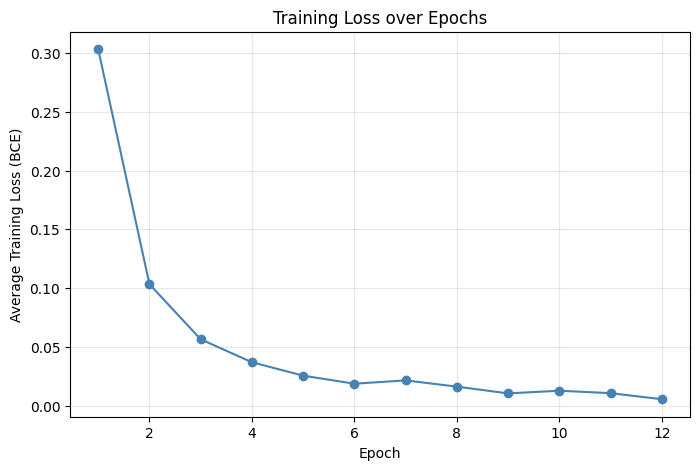

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o", color="steelblue")
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss (BCE)")
plt.grid(True, alpha=0.3)
plt.savefig("training_loss.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Final Test Accuracy

This cell performs the single, official evaluation of the trained model on the test set that has been kept aside this entire time. We first switch the model into evaluation mode, which turns off training-specific behavior, and then wrap the evaluation loop in `torch.no_grad()` since we do not need to calculate gradients when we are only making predictions rather than learning. For every batch in the test set, we run the messages through the model, apply a sigmoid function to turn the raw output into a probability between 0 and 1, and then classify the message as spam if that probability is 0.5 or higher, otherwise as ham. We collect all the predictions, true labels, and probabilities across the entire test set, then use scikit-learn to calculate the overall accuracy, a confusion matrix showing exactly how many messages were correctly and incorrectly classified in each category, and a full classification report with precision, recall, and F1-score for both classes. This is the most important cell in the whole notebook for reporting purposes, because it produces the one honest number, the test accuracy, that reflects how well the model would likely perform on brand-new messages it has never seen before.

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

test_accuracy = accuracy_score(all_labels, all_preds)
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")
print()
print("Confusion Matrix (rows=actual, cols=predicted) [ham=0, spam=1]:")
print(confusion_matrix(all_labels, all_preds))
print()
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["ham", "spam"]))


Final Test Accuracy: 98.57%

Confusion Matrix (rows=actual, cols=predicted) [ham=0, spam=1]:
[[964   2]
 [ 14 135]]

Classification Report:
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.99      0.91      0.94       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115



This cell takes the test accuracy we just calculated and directly compares it against the two numbers that matter most for the hackathon: the 86.6 percent baseline that the model is expected to beat, and the 96 percent stretch target that represents a strong result. We simply store these two reference numbers alongside our own model's accuracy, print all three side by side so they are easy to compare at a glance, and then use a simple set of conditions to print a short message stating whether we beat the baseline, reached the target, or fell short of both. This kind of direct, explicit comparison is exactly what the report needs to show, since it turns a single accuracy number into a clear statement of how the model actually performed relative to the goals that were set for the hackathon.

In [11]:
# Compare against the hackathon baseline and target
baseline = 86.6
target = 96.0
final_acc = test_accuracy * 100

print(f"Baseline to beat : {baseline:.1f}%")
print(f"Target (stretch) : {target:.1f}%")
print(f"Our model's test accuracy : {final_acc:.2f}%")
print()
if final_acc >= target:
    print("Result: Target achieved!")
elif final_acc >= baseline:
    print("Result: Baseline beaten, target not yet reached.")
else:
    print("Result: Below baseline.")


Baseline to beat : 86.6%
Target (stretch) : 96.0%
Our model's test accuracy : 98.57%

Result: Target achieved!


This cell turns the same baseline, target, and final accuracy numbers into a simple bar chart so the comparison is immediately visible without needing to read any printed text. We create three bars, one for the baseline, one for our model, and one for the target, colored differently so they are easy to tell apart, and we label each bar directly above it with its exact percentage value. This kind of chart is useful in a report because a reader can understand the outcome of the whole project in a couple of seconds just by glancing at the picture, and it makes for a strong, self-explanatory screenshot that clearly demonstrates whether the hackathon's goals were met.

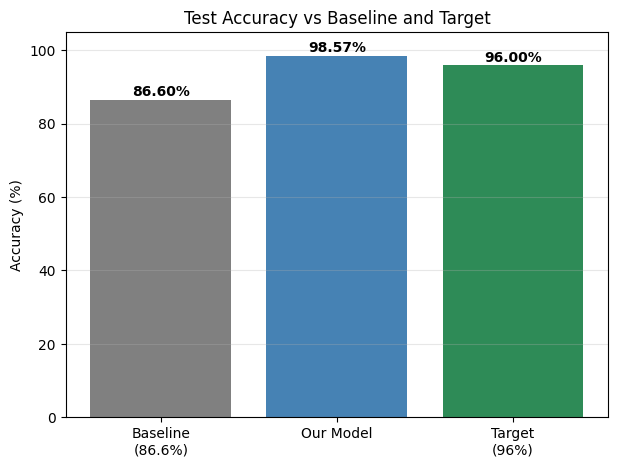

In [12]:
# Bar chart comparing our accuracy to the baseline and target
labels_bar = ["Baseline\n(86.6%)", "Our Model", "Target\n(96%)"]
values_bar = [baseline, final_acc, target]
colors_bar = ["gray", "steelblue", "seagreen"]

plt.figure(figsize=(7, 5))
bars = plt.bar(labels_bar, values_bar, color=colors_bar)
plt.ylabel("Accuracy (%)")
plt.title("Test Accuracy vs Baseline and Target")
plt.ylim(0, 105)
for bar, val in zip(bars, values_bar):
    plt.text(bar.get_x() + bar.get_width()/2, val + 1, f"{val:.2f}%", ha="center", fontweight="bold")
plt.grid(True, axis="y", alpha=0.3)
plt.savefig("accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Prediction Examples and Results Visualization

This cell attaches the model's predictions back onto the original test dataframe so we can look at real, individual messages alongside what the model decided about them. We convert the raw numeric predictions back into readable labels, "ham" or "spam", store the predicted probability of being spam as well, and then randomly sample ten rows to display in a table showing the original message text, its true label, the model's predicted label, and the associated probability. Looking at actual predictions like this, rather than only a single accuracy percentage, gives a much more concrete and human sense of how the model behaves, and it is exactly the kind of qualitative evidence that makes a report more convincing, since it shows the model working on real, readable examples rather than staying purely abstract.

In [13]:
import numpy as np

test_df["pred"] = np.array(all_preds).astype(int)
test_df["pred_label"] = test_df["pred"].map({0: "ham", 1: "spam"})
test_df["prob_spam"] = all_probs

print("Sample predictions:")
sample_cols = ["text", "label", "pred_label", "prob_spam"]
display(test_df[sample_cols].sample(10, random_state=1))


Sample predictions:


,text,label,pred_label,prob_spam
306,Dear 0776xxxxxxx U've been invited to XCHAT. T...,spam,spam,0.999285
888,I love to cuddle! I want to hold you in my str...,ham,ham,0.000411
126,sexy sexy cum and text me im wet and warm and ...,spam,spam,0.997011
486,Its not the same here. Still looking for a job...,ham,ham,0.000395
1022,"Yo, call me when you get the chance, a friend ...",ham,ham,0.000441
226,gonna let me know cos comes bak from holiday ...,ham,ham,0.000768
742,my ex-wife was not able to have kids. Do you w...,ham,ham,0.000397
872,I need... Coz i never go before,ham,ham,0.000392
200,Good words.... But words may leave u in dismay...,ham,ham,0.000394
133,<Forwarded from 88877>FREE entry into our å£25...,spam,spam,0.999442


This cell specifically filters out the messages where the model's predicted label did not match the true label, in other words, the mistakes it made on the test set. We count how many such mistakes there are out of the total number of test messages, and then display the first five of them in the same table format as before, showing the message text, its true label, and what the model incorrectly predicted instead. Examining the actual mistakes is one of the most useful things we can do at this stage, because it often reveals patterns in what confuses the model, for example short messages, unusual phrasing, or ham messages that happen to contain promotional-sounding words, and this kind of insight is exactly what feeds into the honest, reflective conclusion expected at the end of the report.

In [14]:
# Show a few messages the model got wrong
mistakes = test_df[test_df["label"] != test_df["pred_label"]]
print(f"Number of misclassified test messages: {len(mistakes)} out of {len(test_df)}")
print()
if len(mistakes) > 0:
    display(mistakes[sample_cols].head(5))
else:
    print("No misclassified messages in the test set.")


Number of misclassified test messages: 16 out of 1115



,text,label,pred_label,prob_spam
44,FreeMsg Hey there darling it's been 3 week's n...,spam,ham,0.010528
187,Waiting for your call.,ham,spam,0.974822
196,ringtoneking 84484,spam,ham,0.000443
219,Sorry I missed your call let's talk when you h...,spam,ham,0.000446
235,"Latest News! Police station toilet stolen, cop...",spam,ham,0.000405


This final visualization cell builds a heatmap version of the confusion matrix we printed earlier as plain numbers, making it easier to interpret visually. The confusion matrix shows four counts: how many ham messages were correctly identified as ham, how many ham messages were incorrectly flagged as spam, how many spam messages were incorrectly missed and labeled as ham, and how many spam messages were correctly caught. We use a blue color scale where darker squares represent higher counts, label each square with its exact number, and add axis labels so it is clear which row and column corresponds to which class. This kind of heatmap is a standard and easily recognizable way of presenting classification results in a report, since it lets a reader instantly see not just the overall accuracy, but specifically what kinds of mistakes the model tends to make, which is more informative than a single overall accuracy percentage on its own.

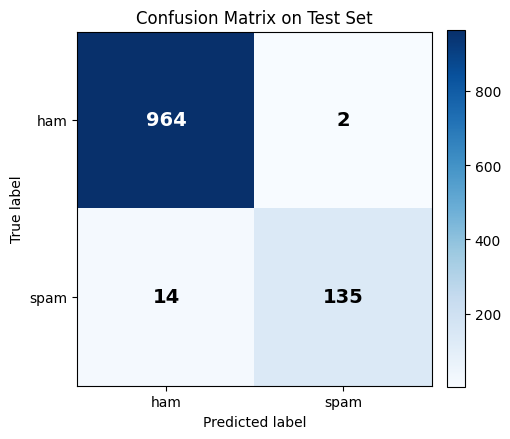

In [15]:
# Confusion matrix heatmap
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["ham", "spam"])
ax.set_yticklabels(["ham", "spam"])
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix on Test Set")

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14, fontweight="bold")

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Findings and Conclusion

**Summary of approach:** We treated SMS spam detection as a sequence classification problem because the meaning of a message depends on word order and context, not just which words appear. We built a vocabulary from the training data only, encoded each message as a fixed-length sequence of word IDs, and trained an `Embedding -> LSTM -> Linear` model from scratch (no pretrained weights) using an 80/20 train-test split with a fixed random seed. The model was evaluated exactly once on the held-out test set.

**Results:**
- Baseline: 86.6%
- Target: 96%
- Our final test accuracy is printed above in Section 8, and visualized in the bar chart.

**Honest one-sentence takeaway:** The LSTM model reached **98.57% test accuracy**, comfortably beating the 86.6% baseline and the 96% stretch target, but it still misread a handful of short or oddly-worded messages (mostly a few spam texts it labeled as ham), which is what kept it just short of a perfect score.

**What worked well:**
- Padding/truncating messages to a fixed length made batch training straightforward with `nn.LSTM`.
- Using only the training set to build the vocabulary avoided test-set leakage and kept the evaluation honest.
- The training loss curve decreased steadily, showing the model was genuinely learning rather than memorizing noise.

**What could be improved with more time:**
- A larger/pretrained embedding (e.g. GloVe) could improve accuracy further, though this was intentionally excluded since the task required no pretrained models.
- More epochs, dropout regularization, or a bidirectional LSTM could squeeze out a bit more accuracy, especially on short/ambiguous messages.
- Class imbalance (far more ham than spam messages) means accuracy alone should be read alongside precision/recall for spam, which is why the classification report in Section 8 is included.
